# Deeper Neural Networks

Let's look back at our logistic regression neural network example. In the image below, we represented what the forward propagation flow looks like. Now there is one important thing to notice, and that is that this logistic regression neural network is actually *extremely shallow*, as there are **no hidden layers**! How so?

<img src="./assets/deeper_neural_networks/new_log_reg.png" width=600>

In fact, what exactly does a neuron in a neural network do? The purpose of a neuron is 2-fold: 
- transforms the inputs doing a linear transformation (generally $ w x+b$)
- uses an activation function (generally sigmoid, or another activation function)

A more correct representation of the neural network is then as follows:

<img src='assets/deeper_neural_networks/new_small_log.png' width='40%'>

This means that there is only **one neuron** in the logistic regression neural network -- basically a neuron in the output layer. It takes inputs that we *know*, and it directly outputs the observed output, with no layers in between. If this is the case, the neural network is a **1-layer neural network**.

To make it even more clear, let's look at the network on the left below, which you might remember from a previous lesson. You can think of this network as a logistic regression-kind neural network, but with an extra layer plugged in with four nodes. This extra layer is a hidden layer, because we do *not directly observe the output of this layer*. This network is a **2-layer neural network**, or a neural network with 1 hidden layer.

<img src='assets/deeper_neural_networks/new_two_network.png'>

Why is this picture on the left hand side a 2-layer neural network? Don't we see 3 layers of nodes? Well, technically, the input layer is not a layer: no transformations happen here, it's simply a layer of inputs. That's why we included the example on the right hand side above. This is basically (again) another way of representing the logistic regression example, the same type of network as the one you've seen in the image right before. Sometimes the input layer will be denoted with actual nodes, sometimes it won't. Just remember that this layer does not count as an *actual* layer. When we refer to it, we'll say it's layer with index 0.

## Deeper network notation

<img src='assets/deeper_neural_networks/new_small_deeper.png' width='700'>

Let's look at this network going forward. With deeper networks, we'll need to introduce new notation. Generally, the output of layer $j$ is denoted as $a^{[j]}$.

For our 2-layer neural network above, this means that:

- $x = a^{[0]}$  as x is what comes out of the input layer
- $a^{[1]} = \begin{bmatrix} a^{[1]}_1  \\ a^{[1]}_2 \\ a^{[1]}_3  \\\end{bmatrix}$ is the value generated by the hidden layer
- $\hat y =  a^{[2]}$, the output layer will generate a value $a^{[2]}$, which is equal to $\hat y$

Remember that in each of the nodes in the hidden layer, a linear transformation will take place, as well as a transformation because of an activation function.

Let's look at the first node in the hidden layer. The linear transformation that takes place is $ z^{[1]}_1 = w^{[1]}_1 x +b^{[1]}_1$, and the activation  $a^{[1]}_1= f(z^{[1]}_1)$. Notice how we use $f$ here instead of $\sigma$. In fact, we don't have to use the sigmoid as an activation function, there are numerous other options!

extending this to the two other nodes in the hidden layer, this gets us to the following equations for the hidden layer:

$ z^{[1]}_1 = w^{[1]}_1 x +b^{[1]}_1$ and  $a^{[1]}_1= f(z^{[1]}_1)$

$ z^{[1]}_2 = w^{[1]}_2 x +b^{[1]}_2$ and $a^{[1]}_2= f(z^{[1]}_2)$

$ z^{[1]}_3 = w^{[1]}_3 x +b^{[1]}_3$ and $a^{[1]}_3= f(z^{[1]}_3)$

Now, let's discuss the dimensions of all these elements.

$w^{[1]} = \begin{bmatrix} w^{[1]}_{1,1}  & w^{[1]}_{2,1} & w^{[1]}_{3,1}  \\ w^{[1]}_{1,2}  & w^{[1]}_{2,2} & w^{[1]}_{3,2}\end{bmatrix}$

where, eg. $w^{[1]}_{1,2}$ denotes the weight of the arrow going from $x_2$ into the first note of the hidden layer.

When multiplying the transposed (making it a 2 x 3 matrix) of this matrix $w^{[1]T}_1$ with $x = \begin{bmatrix} x_1  \\x_2\end{bmatrix}$

and add $b^{[1]} = \begin{bmatrix} b^{[1]}_1  \\b^{[1]}_2 \\ b^{[1]}_3 \end{bmatrix}$, we obtain $z^{[1]} = \begin{bmatrix} z^{[1]}_1  \\z^{[1]}_2 \\ z^{[1]}_3 \end{bmatrix}$. Similarly, we have $a^{[1]} = \begin{bmatrix} a^{[1]}_1  \\a^{[1]}_2 \\ a^{[1]}_3 \end{bmatrix}$ and corresponding sigmoid functions.

Now, let's try and move forward in our network. Recall that 

$x = \begin{bmatrix} x_1  \\x_2\end{bmatrix} \equiv a^{[0]}$ and that $a^{[2]} = \hat y$

Then, given input $x$:

$z^{[1]} = w^{[1]T} a^{[0]} + b^{[1]}$

$a^{[1]} = f(z^{[1]})$

$z^{[2]} = w^{[2]T} a^{[1]} + b^{[2]}$

$a^{[2]} = f(z^{[1]})$

**Some questions to think about** 
- What are the dimensions of the matrices associated here?
- The 4 expressions above don't take into account several training samples. Imagine we use a superscript (i). How do you rewrite these expressions?

$z^{[1](i)} = w^{[1]T} a^{[0](i)} + b^{[0]}$

$a^{[1](i)} = f(z^{[1](i)})$

$z^{[2](i)} = w^{[2]T} a^{[1](i)} + b^{[2]}$

$a^{[2](i)} = f(z^{[1](i)})$

In the lab, you'll learn how to vectorize this!

## Activation functions

Until now, we've only discussed the sigmoid activation function. The sigmoid function is nearly always the go-to in the output layer of a binary classification problem, but in hidden layers, there are many other possible activation functions. In the code block below, you can find some functions we created so we can plot them below. Note that we plot the actual activation functions as well as their derivatives!

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

def sigmoid(x, derivative=False):
    f = 1 / (1 + np.exp(-x))
    if (derivative == True):
        return f * (1 - f)
    return f

def tanh(x, derivative=False):
    f = np.tanh(x)
    if (derivative == True):
        return (1 - (f ** 2))
    return np.tanh(x)

def relu(x, derivative=False):
    f = np.zeros(len(x))
    if (derivative == True):
        for i in range(0, len(x)):
            if x[i] > 0:
                f[i] = 1  
            else:
                f[i] = 0
        return f
    for i in range(0, len(x)):
        if x[i] > 0:
            f[i] = x[i]  
        else:
            f[i] = 0
    return f

def leaky_relu(x, leakage = 0.05, derivative=False):
    f = np.zeros(len(x))
    if (derivative == True):
        for i in range(0, len(x)):
            if x[i] > 0:
                f[i] = 1  
            else:
                f[i] = leakage
        return f
    for i in range(0, len(x)):
        if x[i] > 0:
            f[i] = x[i]  
        else:
            f[i] = x[i]* leakage
    return f

def arctan(x, derivative=False):
    if (derivative == True):
        return 1/(1+np.square(x))
    return np.arctan(x)

z = np.arange(-10, 10, 0.2)

## The sigmoid function 

Let's have a look at the sigmoid again. Recall that the mathematical expression of the sigmoid is $ a=\dfrac{1}{1+ \exp(-z)}$, and this outputs activation values somewhere between 0 and 1.

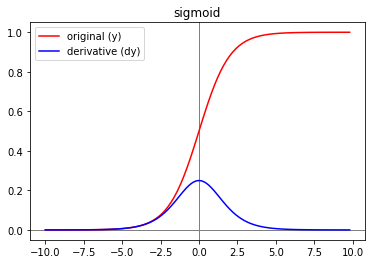

In [ ]:
y = sigmoid(z)
dy = sigmoid(z, derivative=True)
plt.title('sigmoid')
plt.axhline(color='gray', linewidth=1,)
plt.axvline(color='gray', linewidth=1,)
plt.plot(z, y, 'r', label='original (y)')
plt.plot(z, dy, 'b', label='derivative (dy)')
plt.legend();

## The hyperbolic tangent (tanh) function 

The hyperbolic tangent (or tanh) function goes between -1 and +1, and is in fact a shifted version of the sigmoid function, with formula $ a=\dfrac{\exp(z)- \exp(-z)}{\exp(z)+ \exp(-z)}$. For intermediate layers, the tanh function generally performs pretty well because, with values between -1 and +1, the means of the activations coming out are closer to zero!

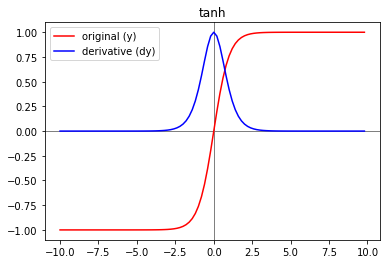

In [ ]:
y = tanh(z)
dy = tanh(z, derivative=True)
plt.title('tanh')
plt.axhline(color='gray', linewidth=1,)
plt.axvline(color='gray', linewidth=1,)
plt.plot(z, y, 'r', label='original (y)')
plt.plot(z, dy, 'b', label='derivative (dy)')
plt.legend();

A disadvantage of both tanh and sigmoid activation functions is that when $z$ gets quite large or small, the derivative of the slopes of these functions become very small, generally 0.0001. This will slow down gradient descent. You can see in the tanh plot that this already starts happening for values of $z > 2$ or $z < 2$. The next few activation functions will try to overcome this issue. 

## The inverse tangent (arctan) function 

The inverse tangent (arctan) function has a lot of the same qualities that tanh has, but the range roughly goes from -1.6 to 1.6, and  the slope is more gentle than the one we saw using the tanh function.

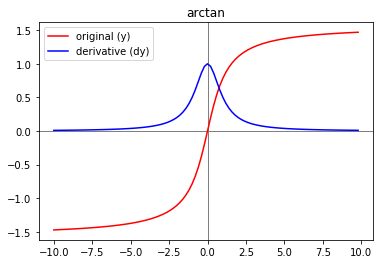

In [ ]:
y = arctan(z)
dy = arctan(z, derivative = True)
plt.title('arctan')
plt.axhline(color='gray', linewidth=1,)
plt.axvline(color='gray', linewidth=1,)
plt.plot(z, y, 'r', label='original (y)')
plt.plot(z, dy, 'b', label='derivative (dy)')
plt.legend();

## The Rectified Linear Unit function 

This is probably the most popular activation function, along with the tanh! The fact that the activation is exactly 0 when $z <0$  is slightly cumbersome when taking derivatives though. 

$$a=\max(0, z)$$

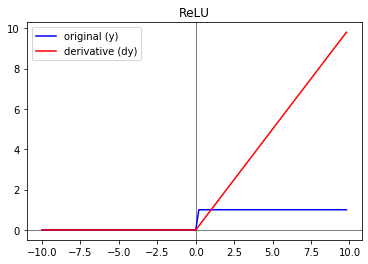

In [ ]:
plt.title('ReLU')
y = relu(z)
dy = relu(z, derivative=True)
plt.axhline(color='gray', linewidth=1,)
plt.axvline(color='gray', linewidth=1,)
plt.plot(z, dy, 'b', label='original (y)')
plt.plot(z, y, 'r', label='derivative (dy)')
plt.legend();

## The leaky Rectified Linear Unit function 

The leaky ReLU solves the derivative issue by allowing for the activation to be slightly negative when $z <0$. 

$$a=\max(0.001*z ,z)$$

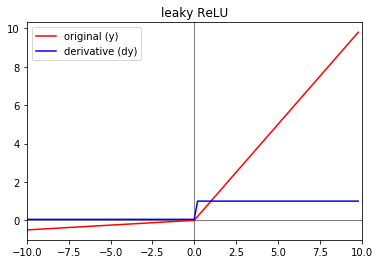

In [ ]:
# the default leakage here is 0.05!
y = leaky_relu(z)
dy = leaky_relu(z, derivative=True)
plt.axhline(color='gray', linewidth=1,)
plt.axvline(color='gray', linewidth=1,)
plt.title('leaky ReLU')
plt.xlim(-10,10)
plt.plot(z, y, 'r', label='original (y)')
plt.plot(z, dy, 'b', label='derivative (dy)')
plt.legend();

---

## Getting Started

Run the cell below to import everything we'll need for this lab.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import keras
from keras.models import Sequential
from keras.layers import Dense
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler, LabelBinarizer

Using TensorFlow backend.


For this lab, we'll be working with the [Boston Breast Cancer Dataset](https://www.kaggle.com/uciml/breast-cancer-wisconsin-data). Although we're importing this dataset directly from scikit-learn, the Kaggle link above contains a detailed explanation of the dataset, in case you're interested. We recommend you take a minute to familiarize yourself with the dataset before digging in. 

In the cell below:

* Call `load_breast_cancer()` to store the dataset  
* Access the `.data`, `.target`, and `.feature_names` attributes and store them in the appropriate variables below

In [ ]:
bc_dataset = load_breast_cancer()
data = bc_dataset.data
target = bc_dataset.target
col_names = bc_dataset.feature_names

Now, let's create a DataFrame so that we can see the data and explore it a bit more easily with the column names attached. 

- In the cell below, create a pandas DataFrame from `data` (use `col_names` for column names)  
- Print the `.head()` of the DataFrame

In [ ]:
df = pd.DataFrame(data, columns=col_names)
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## Getting the Data Ready for Deep Learning

In order to pass this data into a neural network, we'll need to make sure that the data:

* is purely numerical
* contains no missing values
* is normalized 

Let's begin by calling the DataFrame's `.info()` method to check the datatype of each feature.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
mean radius                569 non-null float64
mean texture               569 non-null float64
mean perimeter             569 non-null float64
mean area                  569 non-null float64
mean smoothness            569 non-null float64
mean compactness           569 non-null float64
mean concavity             569 non-null float64
mean concave points        569 non-null float64
mean symmetry              569 non-null float64
mean fractal dimension     569 non-null float64
radius error               569 non-null float64
texture error              569 non-null float64
perimeter error            569 non-null float64
area error                 569 non-null float64
smoothness error           569 non-null float64
compactness error          569 non-null float64
concavity error            569 non-null float64
concave points error       569 non-null float64
symmetry error             569 

From the output above, we can see that the entire dataset is already in numerical format. We can also see from the counts that each feature has the same number of entries as the number of rows in the DataFrame -- that means that no feature contains any missing values. Great!

Now, let's check to see if our data needs to be normalized. Instead of doing statistical tests here, let's just take a quick look at the `.head()` of the DataFrame again. Do this in the cell below.

In [ ]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


As we can see from comparing `mean radius` and `mean area`, columns are clearly on different scales, which means that we need to normalize our dataset. To do this, we'll make use of scikit-learn's `StandardScaler()` class. 

In the cell below, instantiate a `StandardScaler` and use it to create a normalized version of our dataset.

In [ ]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)

## Binarizing our Labels

If you took a look at the data dictionary on Kaggle, then you probably noticed the target for this dataset is to predict if the sample is "M" (Malignant) or "B" (Benign). This means that this is a **_Binary Classification_** task, so we'll need to binarize our labels. 

In the cell below, make use of scikit-learn's `LabelBinarizer()` class to create a binarized version of our labels.

In [ ]:
binarizer = LabelBinarizer()
labels = binarizer.fit_transform(target)

## Building our MLP

Now, we'll build a small **_Multi-Layer Perceptron_** using Keras in the cell below. Our first model will act as a baseline, and then we'll make it bigger to see what happens to model performance. 

In the cell below:

* Instantiate a `Sequential()` Keras model   
* Use the model's `.add()` method to add a `Dense` layer with 10 neurons and a `'tanh'` activation function. Also set the `input_shape` attribute to `(30,)`, since we have 30 features  
* Since this is a binary classification task, the output layer should be a `Dense` layer with a single neuron, and the activation set to `'sigmoid'`

In [ ]:
model_1 = Sequential()
model_1.add(Dense(5, activation='tanh', input_shape=(30,)))
model_1.add(Dense(1, activation='sigmoid'))

### Compiling the Model

Now that we've created the model, the next step is to compile it. 

In the cell below, compile the model. Set the following hyperparameters:

* `loss='binary_crossentropy'`
* `optimizer='sgd'`
* `metrics=['accuracy']`

In [ ]:
model_1.compile(loss='binary_crossentropy', optimizer='sgd', metrics=['accuracy'])

### Fitting the Model

Now, let's fit the model. Set the following hyperparameters:

* `epochs=25`
* `batch_size=1`
* `validation_split=0.2`

In [ ]:
results_1 = model_1.fit(scaled_data, labels, epochs=25, batch_size=1, validation_split=0.2)

Train on 455 samples, validate on 114 samples
Epoch 1/25
455/455 [==============================] - 1s 1ms/step - loss: 0.2832 - acc: 0.8879 - val_loss: 0.1785 - val_acc: 0.9737
Epoch 2/25
455/455 [==============================] - 0s 912us/step - loss: 0.1193 - acc: 0.9714 - val_loss: 0.1367 - val_acc: 0.9737
Epoch 3/25
455/455 [==============================] - 0s 879us/step - loss: 0.0911 - acc: 0.9780 - val_loss: 0.1234 - val_acc: 0.9825
Epoch 4/25
455/455 [==============================] - 0s 879us/step - loss: 0.0795 - acc: 0.9802 - val_loss: 0.1198 - val_acc: 0.9649
Epoch 5/25
455/455 [==============================] - 0s 895us/step - loss: 0.0729 - acc: 0.9758 - val_loss: 0.1068 - val_acc: 0.9825
Epoch 6/25
455/455 [==============================] - 0s 881us/step - loss: 0.0684 - acc: 0.9758 - val_loss: 0.1093 - val_acc: 0.9649
Epoch 7/25
455/455 [==============================] - 0s 890us/step - loss: 0.0643 - acc: 0.9824 - val_loss: 0.1065 - val_acc: 0.9649
Epoch 8/25
455/455

Note that when you call a Keras model's `.fit()` method, it returns a Keras callback containing information on the training process of the model. If you examine the callback's `.history` attribute, you'll find a dictionary containing both the training and validation loss, as well as any metrics we specified when compiling the model (in this case, just accuracy). 

Let's quickly plot our validation and accuracy curves and see if we notice anything. Since we'll want to do this anytime we train an MLP, its worth wrapping this code in a function so that we can easily reuse it. 

In the cell below, we created a function for visualizing the loss and accuracy metrics.

In [ ]:
def visualize_training_results(results):
    history = results.history
    plt.figure()
    plt.plot(history['val_loss'])
    plt.plot(history['loss'])
    plt.legend(['val_loss', 'loss'])
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.show()
    
    plt.figure()
    plt.plot(history['val_acc'])
    plt.plot(history['acc'])
    plt.legend(['val_acc', 'acc'])
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.show()

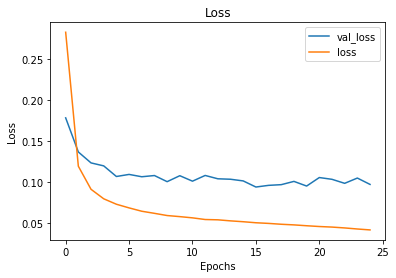

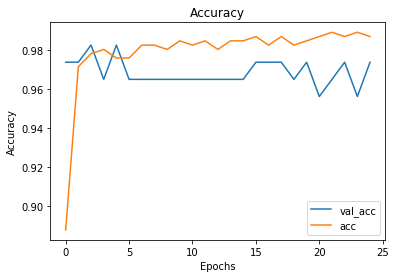

In [ ]:
visualize_training_results(results_1)

## Detecting Overfitting

You'll probably notice that the model did pretty well! It's always recommended to visualize your training and validation metrics against each other after training a model. By plotting them like this, we can easily detect when the model is starting to overfit. We can tell that this is happening by seeing the model's training performance steadily improve long after the validation performance plateaus. We can see that in the plots above as the training loss continues to decrease and the training accuracy continues to increase, and the distance between the two lines gets greater as the epochs gets higher. 

## Iterating on the Model

By adding another hidden layer, we can a given the model the ability to capture more high-level abstraction in the data. However, increasing the depth of the model also increases the amount of data the model needs to converge to answer, because with a more complex model comes the "Curse of Dimensionality", thanks to all the extra trainable parameters that come from adding more size to our network. 

If there is complexity in the data that our smaller model was not big enough to catch, then a larger model may improve performance. However, if our dataset isn't big enough for the new, larger model, then we may see performance decrease as then model "thrashes" about a bit, failing to converge. Let's try and see what happens. 

In the cell below, recreate the model that you created above, with one exception. In the model below, add a second `Dense` layer with `'tanh'` activation function and 5 neurons after the first. The network's output layer should still be a `Dense` layer with a single neuron and a `'sigmoid'` activation function, since this is still a binary classification task. 

Create, compile, and fit the model in the cells below, and then visualize the results to compare the history.

In [ ]:
model_2 = Sequential()
model_2.add(Dense(10, activation='tanh', input_shape=(30,)))
model_2.add(Dense(5, activation='tanh'))
model_2.add(Dense(1, activation='sigmoid'))

In [ ]:
model_2.compile(loss='binary_crossentropy', optimizer='sgd', metrics=['accuracy'])

In [ ]:
results_2 = model_2.fit(scaled_data, labels, epochs=25, batch_size=1, validation_split=0.2)

Train on 455 samples, validate on 114 samples
Epoch 1/25
455/455 [==============================] - 1s 1ms/step - loss: 0.2657 - acc: 0.9253 - val_loss: 0.2188 - val_acc: 0.9386
Epoch 2/25
455/455 [==============================] - 0s 956us/step - loss: 0.1315 - acc: 0.9670 - val_loss: 0.1403 - val_acc: 0.9649
Epoch 3/25
455/455 [==============================] - 0s 1ms/step - loss: 0.0993 - acc: 0.9758 - val_loss: 0.1417 - val_acc: 0.9474
Epoch 4/25
455/455 [==============================] - 0s 989us/step - loss: 0.0856 - acc: 0.9714 - val_loss: 0.1138 - val_acc: 0.9649
Epoch 5/25
455/455 [==============================] - 0s 942us/step - loss: 0.0746 - acc: 0.9802 - val_loss: 0.0948 - val_acc: 0.9649
Epoch 6/25
455/455 [==============================] - 0s 958us/step - loss: 0.0669 - acc: 0.9824 - val_loss: 0.1338 - val_acc: 0.9474
Epoch 7/25
455/455 [==============================] - 0s 1ms/step - loss: 0.0626 - acc: 0.9802 - val_loss: 0.0950 - val_acc: 0.9649
Epoch 8/25
455/455 [==

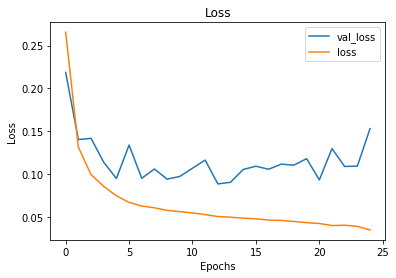

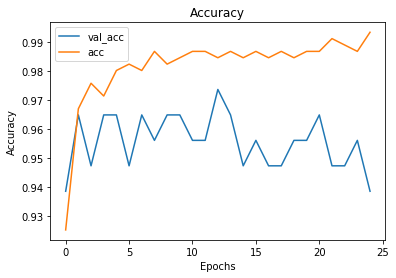

In [ ]:
visualize_training_results(results_2)

## What Happened?

Although the final validation score for both models is the same, this model is clearly worse because it hasn't converged yet. We can tell because of the greater variance in the movement of the `val_loss` and `val_acc` lines. This suggests that we can remedy this by either:

* Decreasing the size of the network, or
* Increasing the size of our training data 

## Visualizing why we Normalize our Data

As a final exercise, let's create a third model that is the same as the first model we created earlier. The only difference is that we will train it on our raw dataset, not the normalized version. This way, we can see how much of a difference normalizing our input data makes.

Create, compile, and fit a model in the cell below. The only change in parameters will be using `data` instead of `scaled_data` during the `.fit()` step.

In [ ]:
model_3 = Sequential()
model_3.add(Dense(5, activation='tanh', input_shape=(30,)))
model_3.add(Dense(1, activation='sigmoid'))

In [ ]:
model_3.compile(loss='binary_crossentropy', optimizer='sgd', metrics=['accuracy'])

In [ ]:
results_3 = model_3.fit(data, labels, epochs=25, batch_size=1, validation_split=0.2)

Train on 455 samples, validate on 114 samples
Epoch 1/25
455/455 [==============================] - 1s 1ms/step - loss: 0.6993 - acc: 0.5912 - val_loss: 0.6331 - val_acc: 0.7719
Epoch 2/25
455/455 [==============================] - 0s 945us/step - loss: 0.6813 - acc: 0.5890 - val_loss: 0.6022 - val_acc: 0.7719
Epoch 3/25
455/455 [==============================] - 0s 950us/step - loss: 0.6821 - acc: 0.5912 - val_loss: 0.6159 - val_acc: 0.7719
Epoch 4/25
455/455 [==============================] - 0s 1ms/step - loss: 0.6789 - acc: 0.5846 - val_loss: 0.6019 - val_acc: 0.7719
Epoch 5/25
455/455 [==============================] - 0s 903us/step - loss: 0.6806 - acc: 0.5912 - val_loss: 0.5798 - val_acc: 0.7719
Epoch 6/25
455/455 [==============================] - 0s 956us/step - loss: 0.6807 - acc: 0.5912 - val_loss: 0.6372 - val_acc: 0.7719
Epoch 7/25
455/455 [==============================] - 0s 925us/step - loss: 0.6811 - acc: 0.5912 - val_loss: 0.5871 - val_acc: 0.7719
Epoch 8/25
455/455 [

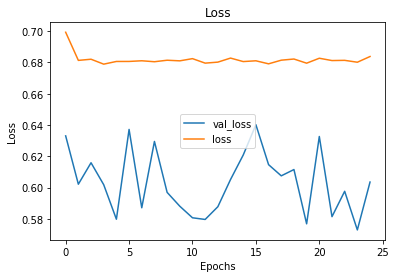

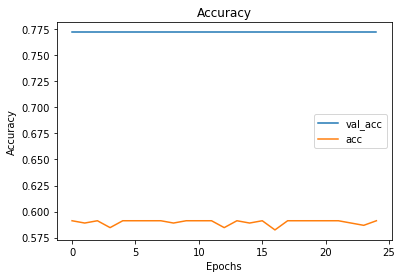

In [ ]:
visualize_training_results(results_3)